In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import hankel1 as H1

In [120]:
def R(theta):
    Rm = np.array([[np.cos(theta), -np.sin(theta)], 
              [np.sin(theta),  np.cos(theta)]])
    
    return Rm

In [121]:
# Relevant Constants
VF = 906091185689731.9 #nm/s Fermi Velocity
a = 0.24595 #nm unit cell length
V0 = 100 # eV
w = -2.8 #eV Hopping
W2 = w ** 2
HBAR = 6.582119569 * 1e-16 #eV s
#HBAR = 1

def R(theta):
    Rm = np.array([[np.cos(theta), -np.sin(theta)], 
              [np.sin(theta),  np.cos(theta)]])
    
    return Rm

Kv = np.array([(4 * np.pi)/(3 * np.sqrt(3) * a), 0])
Kp = [-(4 * np.pi)/(3 * np.sqrt(3) * a), 0]

# Valleys
KVals = []
for i in [0, 60, 120, 180, 240, 300]:
    deg = np.radians(i)
    KVals.append(R(deg) @Kv)

print(KVals)


[array([9.83288942, 0.        ]), array([4.91644471, 8.51553203]), array([-4.91644471,  8.51553203]), array([-9.83288942e+00,  1.20418166e-15]), array([-4.91644471, -8.51553203]), array([ 4.91644471, -8.51553203])]


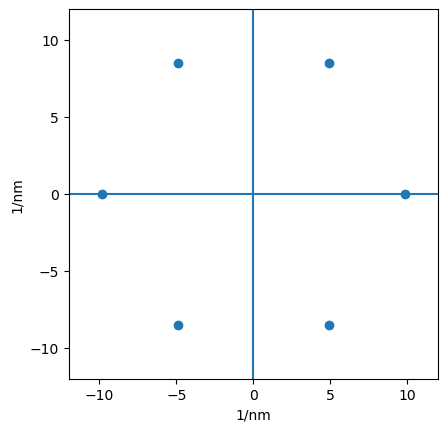

In [122]:
pltK, axK = plt.subplots()

kxList = [x[0] for x in KVals]
kyList = [x[1] for x in KVals]

axK.scatter(kxList, kyList)
axK.set_aspect('equal')
axK.set_xlim(-12, 12)
axK.set_ylim(-12, 12)
axK.set_xlabel('1/nm')
axK.set_ylabel('1/nm')
axK.axhline(0)
axK.axvline(0)

In [123]:
# Onsite Unperturbed Greens Function Sub Lattice AA
# Input energy(scalar), return complex128
def gosAA(energy):
    gc1 = np.sqrt(3) * W2
    gc2 = gc1 * np.pi
    gconsts = np.sqrt(3)*np.pi*W2
    return np.complex128((energy)/(gc2) * np.log((energy**2)/(gc2)) - 1j * np.abs(energy)/(gc1))

def T_AA(energy):
    return V0/(1-gosAA(energy))

# Finite Unperturbed Greens Function Sub Lattice AA
# Input energy(scalar), pos(cartesian vector. numpy arr), return 2x2 matrix complex128
# vpos valley position
def gf(energy, pos, vpos):
    gc = (1j*energy)/(np.sqrt(3)*W2)
    dot = np.dot(vpos, pos)
    rc = (energy * np.linalg.norm(pos)/(VF*HBAR))
    thet = np.arctan2(pos[1], pos[0])

    H1_0 = H1(0, rc)
    H1_1 = H1(1, rc)
    Acos = np.cos(dot)

    AA = -Acos * H1_0
    AB = +np.sin(dot - thet) * H1_1
    BA = +np.sin(dot + thet) * H1_1
    BB = +Acos * H1_0

    return gc * np.array([[AA, AB], [BA, BB]]).astype(np.complex128)

# Sublattice A Density of States
# not including unperturbed
def LDOS_SA(energy, pos, valley):
    gfl = gf(energy, pos, valley)
    GAA, GAB, GBA, GBB = gfl[0, 0], gfl[0, 1], gfl[1, 0], gfl[1, 1]
    TT = T_AA(energy)

    return np.imag(GAA + GBB + TT * (GAA ** 2 + GBA * GAB))

# Try with matrix multiplication
# Seems like expressions are Identical
# Now here I'm including g0
# Seems like g0 is zero
def LDOS_MA(energy, pos, vpos):
    gfl = gf(energy, pos, vpos)
    TT = np.array([[T_AA(energy), 0], [0, 0]])

    res = gfl @ (TT @ gfl)
    tr = np.trace(res)

    return np.imag(tr)

def LDOS_MA_SUM(energy, pos, kvlist):
    res = 0
    for kv in kvlist:
        res += LDOS_MA(energy, pos, kv)
    
    return res

### Comparing LDOS Analytical with Pybinding

In [124]:
pfile = r'/mnt/c/Users/ander/OneDrive/Documents/GitHub/QPI-Scattering/TBCalcs/DiscreteLDOS/asublattice_10x10/SingleDefect/disc_spatial_ldos.csv'
dfA = pd.read_csv(pfile)
dfM = dfA[(dfA["x"]**2 + dfA["y"]**2 > 1) & (dfA["x"]**2 + dfA["y"]**2 < 4)]

In [125]:
xL = np.array(dfM['x'])
yL = np.array(dfM['y'])
EL = np.array(dfM['LDOS at 0.030 eV'])

Text(0.5, 1.0, 'Pybinding A sublattice vacancy origin E=0.03eV')

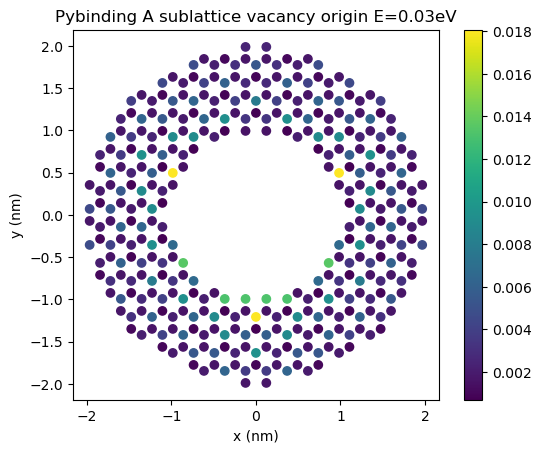

In [126]:
fig1, ax1 = plt.subplots()

sc1 = ax1.scatter(xL, yL, c=EL)
plt.colorbar(sc1)
ax1.set_xlabel("x (nm)")
ax1.set_ylabel("y (nm)")
ax1.set_aspect('equal')
ax1.set_title("Pybinding A sublattice vacancy origin E=0.03eV")

In [147]:
# Creating analytical comparison
# Recall we have a freedom of selecting V0 we might want to make this very big...
aE_list = np.zeros(np.shape(EL))
for i in range(0, len(xL)):
    x = xL[i]
    y = yL[i]
    aE_list[i] = LDOS_MA(0.03, [x, y], KVals[0])

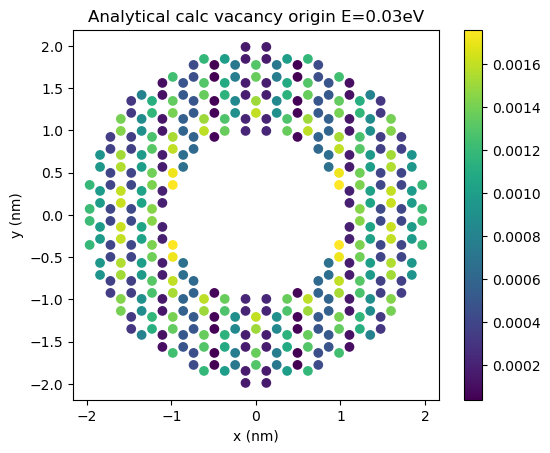

In [148]:
fig2, ax2 = plt.subplots()

sc2 = ax2.scatter(xL, yL, c=aE_list)
plt.colorbar(sc2)

ax2.set_xlabel("x (nm)")
ax2.set_ylabel("y (nm)")
ax2.set_aspect('equal')
ax2.set_title("Analytical calc vacancy origin E=0.03eV")

plt.show()

Text(0.5, 1.0, 'Analytical calc vacancy origin E=0.03eV')

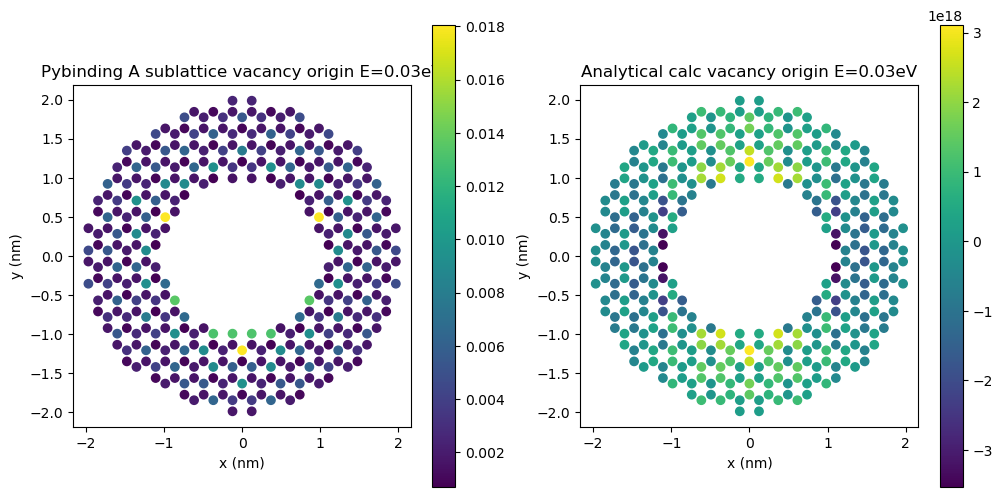

In [64]:
# Side by side
fig3, axs3 = plt.subplots(1, 2, figsize=(12, 6))

sc3a = axs3[0].scatter(xL, yL, c=EL)
plt.colorbar(sc3a)
axs3[0].set_xlabel("x (nm)")
axs3[0].set_ylabel("y (nm)")
axs3[0].set_aspect('equal')
axs3[0].set_title("Pybinding A sublattice vacancy origin E=0.03eV")

sc3b = axs3[1].scatter(xL, yL, c=aE_list)
plt.colorbar(sc3b)
axs3[1].set_xlabel("x (nm)")
axs3[1].set_ylabel("y (nm)")
axs3[1].set_aspect('equal')
axs3[1].set_title("Analytical calc vacancy origin E=0.03eV")


### Comparing Length Scales

In [65]:
# Separation in nm
def Order1(energy, sep, pos):
    sx, sy = sep # location of defect one
    px, py = pos

    rrp1 = np.array([sx - px, sy - py]) #r-r' #defect 1
    rrp2 = np.array([-sx - px, -sy - py]) # defect 2

    T_M = np.array([[T_AA(energy), 0], [0, 0]])

    return gf(energy, rrp1, 1) @ (T_M @ gf(energy, -rrp1, 1)) + gf(energy, rrp2, 1) @ (T_M @ gf(energy, -rrp2, 1))

def Order2(energy, sep, pos):
    sx, sy = sep # location of defect one
    px, py = pos

    rrp1 = np.array([sx - px, sy - py]) #r-r' #defect 1
    rrp2 = np.array([-sx - px, -sy - py]) # defect 2

    # Between 2 and 1. This is 2 - 1
    rb21 = np.array([-sx - sx, sy - sy])

    T_M = np.array([[T_AA(energy), 0], [0, 0]])

    val = gf(energy, rrp2, 1) @ (T_M @ (gf(energy, rb21, 1) @(T_M @ gf(energy, -rrp1, 1)))) + gf(energy, rrp1, 1) @ (T_M @ (gf(energy, -rb21, 1) @(T_M @ gf(energy, -rrp2, 1))))

    return val

In [66]:
seplist = np.linspace(1, 100)

ratiolist = []

for s in seplist:
    Term1 = Order1(0.2, [s, 0], [0, 0])
    Term2 = Order2(0.2, [s, 0], [0, 0])

    rat = np.imag(Term2[0, 0] + Term2[1, 1])/np.abs(Term1[0, 0] + Term1[1, 1])

    ratiolist.append(rat)

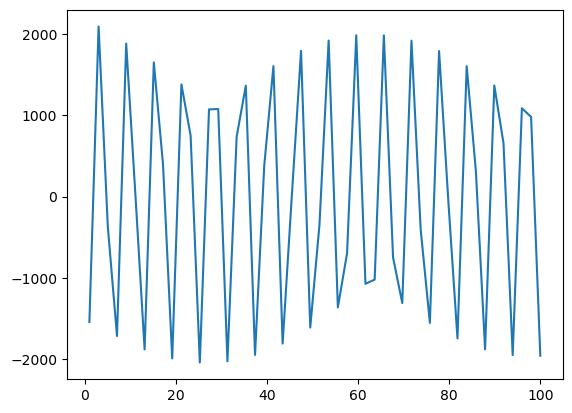

In [67]:
fig1, ax1 = plt.subplots()

ax1.plot(seplist, ratiolist)